# D2.H — Constraint-space exploration of the four-variant checkpoint

**What this is.** A constraint-space *exploration* analysis of the IV.POS.8 four-variant POS campaign — how broadly and deeply each fuzzing architecture probes the RISC Zero zkVM's constraint system. It is the companion to D2.G's *verdict/triage* analysis: **D2.G asks "did we find a soundness bug?"; D2.H asks "how effectively does each architecture explore the space where soundness bugs would live?"**

**The hypothesis it serves.** A soundness bug is an *underconstraint* — a place where the circuit accepts something it should reject. To find one, a fuzzer must (1) reach that constraint location and (2) probe it with a mutation it should reject. So *broader/deeper constraint-space exploration → more chances to sit on top of an underconstraint → higher bug-discovery potential.* This notebook measures the **potential** (exploration), **not** confirmed bugs.

> **Read this first — two honesty caveats.**
> 1. **PROVISIONAL: batch-1 only** (seeds 1234 & 1235 of 3; N=10000). Seed 1236 (batch-2) is pending; treat magnitudes as directional, not final.
> 2. **Exploration ≠ bugs.** D2.G's fault-propagation triage has found **0 confirmed soundness candidates** at N=10000 so far (all accepts are no-ops). This notebook is about *where each architecture looks*, which is the leading indicator for *where a bug could be found* — not a claim that one was.

**The four variants.**
- **V5_control** — pure A4: post-*execution* witness/trace-cell mutation (cTS scheduler, constant floor).
- **V6_uniform** — pure Arguzz: during-*execution* fault injection, round-robin over 11 kinds.
- **V6_cTS** — pure Arguzz, but scheduled by the constrained Thompson-sampling bandit.
- **Hybrid_cTS** — A4 trace-cell + Arguzz execution-fault surfaces together, cTS-scheduled.

In [1]:
import os, sys
os.chdir("/root/arguzz")                 # so the relative DB paths in d2h_lib resolve
sys.path.insert(0, "/root/arguzz/a4/runs/iv_pos_8/d2g")
import json, d2h_lib
d = d2h_lib.load_data()                   # loads the 8 batch-1 N=10000 DBs (live)
print("variants:", d2h_lib.VARIANTS, "| seeds:", d2h_lib.SEEDS, "| N:", d2h_lib.N)
print(json.dumps(d2h_lib.summary(d), indent=2))

variants: ['V5_control', 'V6_uniform', 'V6_cTS', 'Hybrid_cTS'] | seeds: [1234, 1235] | N: 10000
{
  "local": {
    "totals": {
      "V5_control": 47,
      "V6_uniform": 36,
      "V6_cTS": 36,
      "Hybrid_cTS": 49
    },
    "union": 50,
    "common4": 33,
    "exclusive": {
      "V5_control": 0,
      "V6_uniform": 1,
      "V6_cTS": 0,
      "Hybrid_cTS": 0
    }
  },
  "cgc": {
    "totals": {
      "V5_control": 419,
      "V6_uniform": 536,
      "V6_cTS": 653,
      "Hybrid_cTS": 564
    },
    "union": 1001,
    "common4": 99,
    "exclusive": {
      "V5_control": 47,
      "V6_uniform": 3,
      "V6_cTS": 69,
      "Hybrid_cTS": 42
    }
  }
}


## 1. The two dimensions of the constraint space — and why these are the right coverage metrics

A zkVM constraint system has **two structurally distinct kinds of constraints**, and an underconstraint can hide in either. We track one coverage curve for each — they are *not* interchangeable:

- **Local coverage** (`constraint_loc`) — the **per-row / per-cycle** constraints (the `.zir` `EQZ` equalities: "this cell must equal that combination"). A local-loc is "covered" when a mutation makes that specific constraint *fail*. Intuition: *which individual constraints did the fuzzer trigger.*
- **CGC coverage** (compressed global context) — the **global, cross-row** arguments: the memory- and lookup-**permutation** residues that tie the whole trace together. Intuition: *which global, witness-internal structures did the fuzzer perturb.*

A mutation can move CGC without adding a local loc (and vice versa), so the two curves are orthogonal and **jointly span** the surface a soundness bug could occupy. We also show a **rarity-weighted local curve** (each loc weighted `1/(#variants that ever hit it)`) — this rewards reaching *rare/exclusive* constraints rather than re-hitting common ones, i.e. exploration *depth*, which a raw count hides.

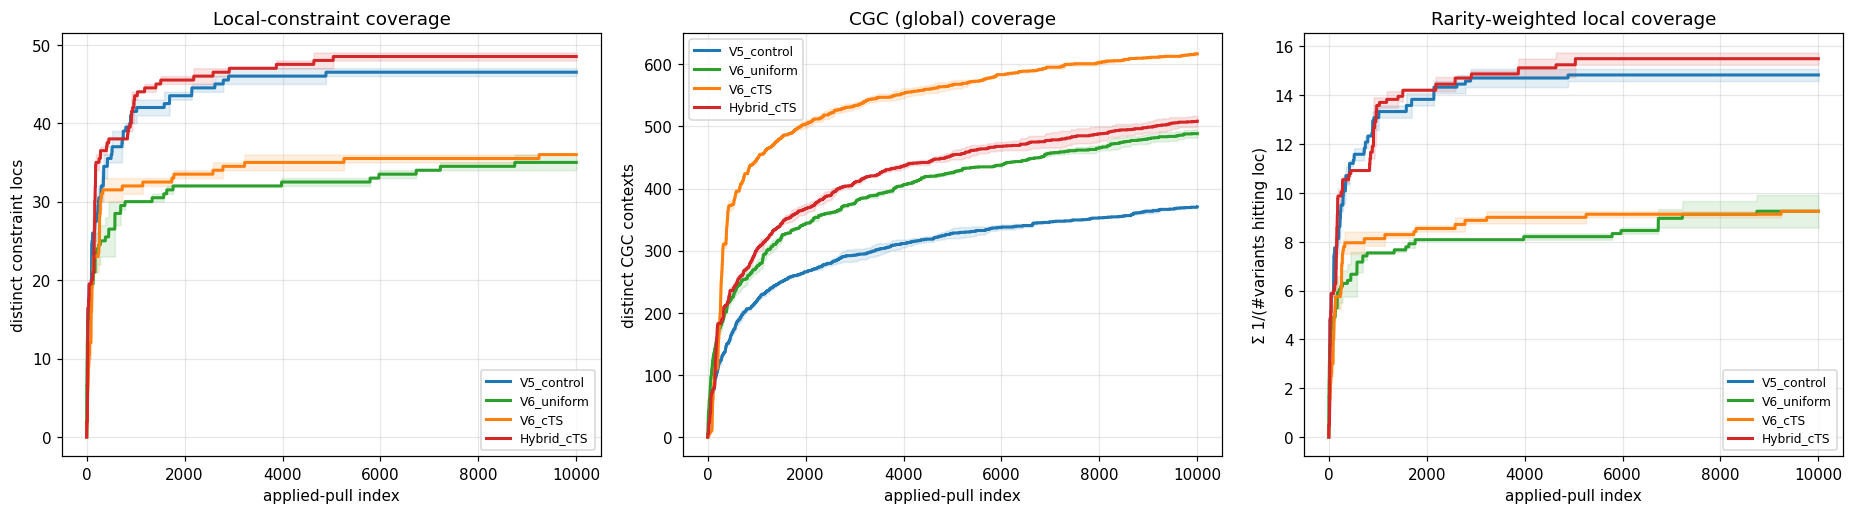

In [2]:
d2h_lib.show(d2h_lib.fig_curves(d))

**How to read the curves.** Each line is the cumulative count of *distinct* locs / CGC contexts discovered as the campaign progresses (mean of the two seeds; shaded band = seed spread). A line that keeps climbing is still finding new territory; a flat tail means saturation. Compare *shapes* (who discovers fastest, who saturates) and *endpoints* (total territory).

The headline pattern: **A4 (V5, Hybrid) climbs higher on the *local* curve; the Arguzz variants climb higher on the *CGC* curve.** The two surfaces explore complementary parts of the constraint system — quantified next.

## 2. Territory decomposition — who reaches what, and what's unique

The central exploration question is **complementarity**: does each architecture reach constraint territory the others can't? We show this three ways, from most-precise to most-intuitive:

1. **UpSet plot (primary, exact).** The modern replacement for high-set Venns. Top bars = the exact size of every intersection region; the dot-matrix below says which variants that region belongs to; the left bars = each variant's total. It is quantitatively precise and scales to all four variants (a 4-circle Venn is geometrically impossible).
2. **Proportional Venn (intuitive glance).** Circle *area* ∝ set size; region numbers are exact. Drawn for the three *surface-distinct* variants `{V5(A4), V6_cTS(Arguzz), Hybrid(both)}` (the geometry is illustrative, the numbers exact).
3. **Composition bars.** Each variant's territory split into exclusive / shared-by-2 / -3 / common-to-all-4 — "how much of what I found is mine alone."

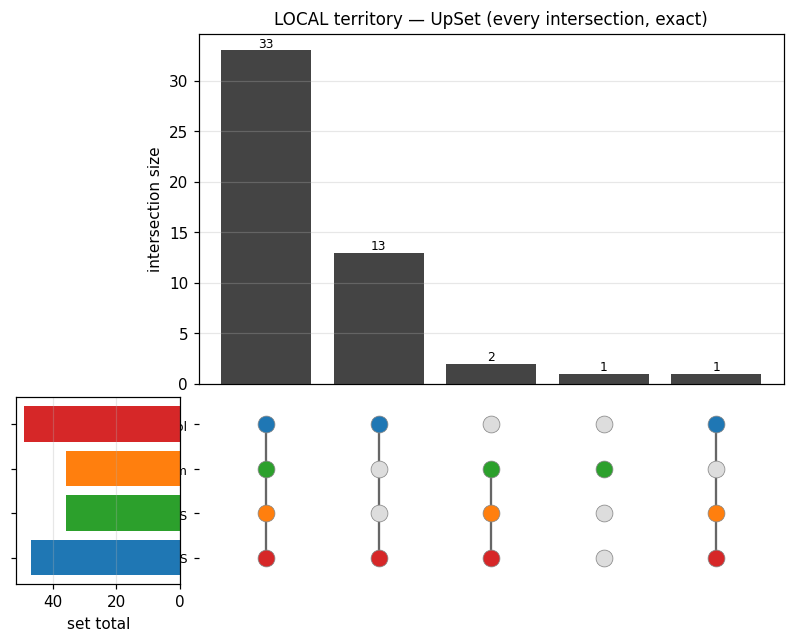

In [3]:
d2h_lib.show(d2h_lib.fig_upset(d, 'local'))

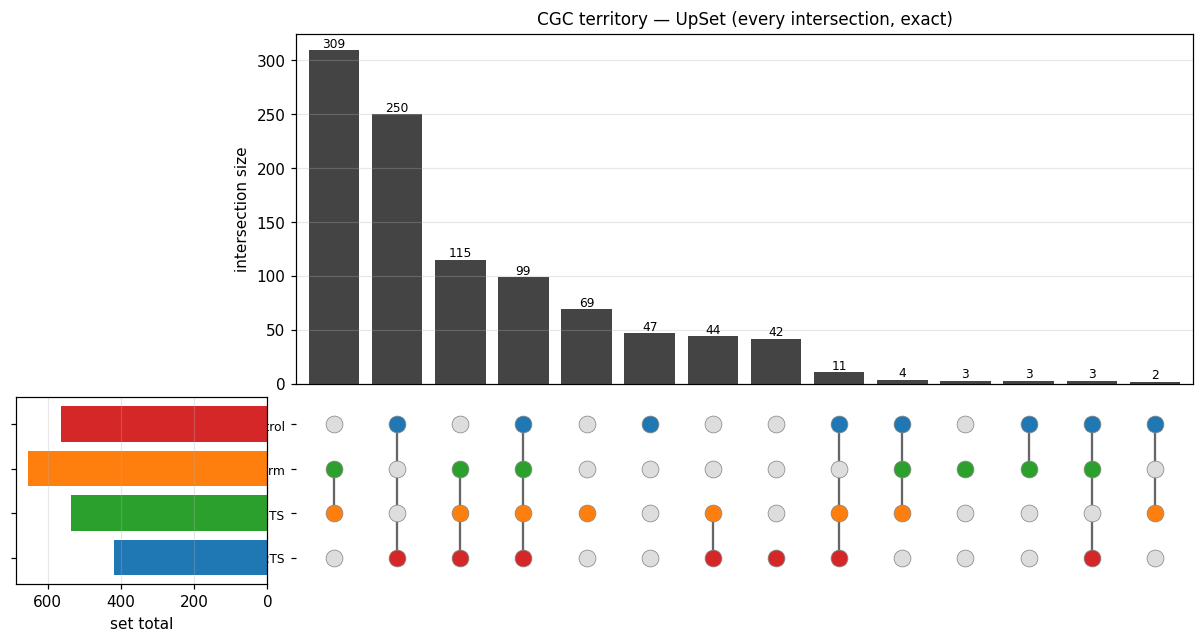

In [4]:
d2h_lib.show(d2h_lib.fig_upset(d, 'cgc'))

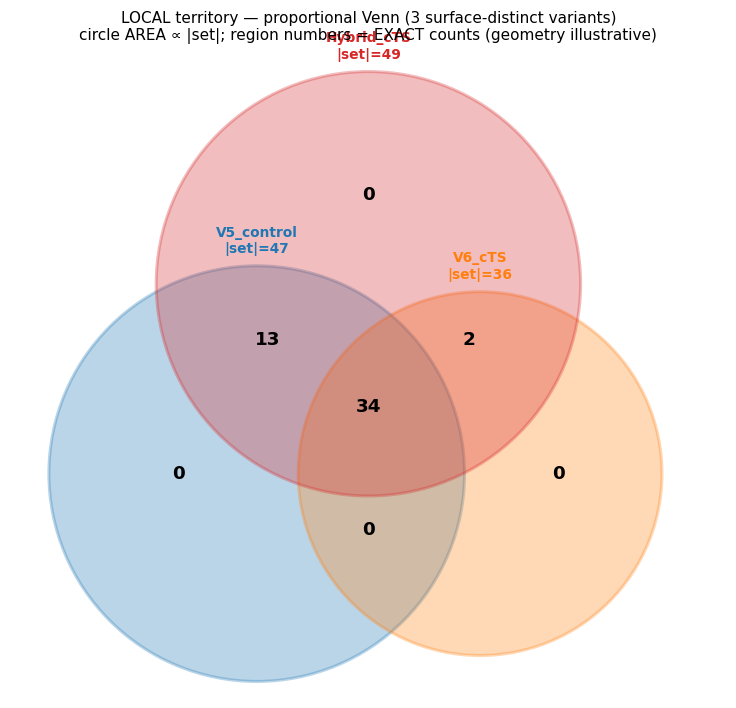

In [5]:
d2h_lib.show(d2h_lib.fig_venn(d, 'local'))

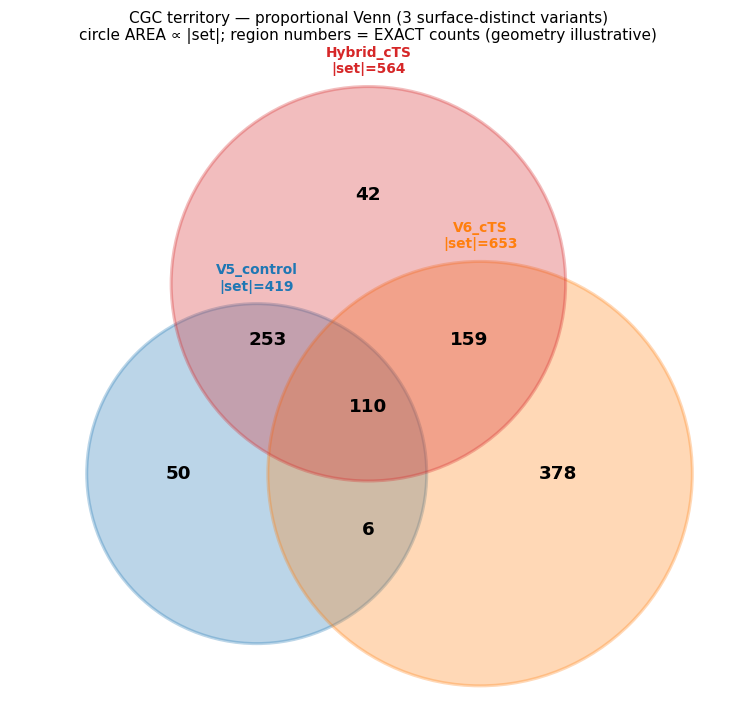

In [6]:
d2h_lib.show(d2h_lib.fig_venn(d, 'cgc'))

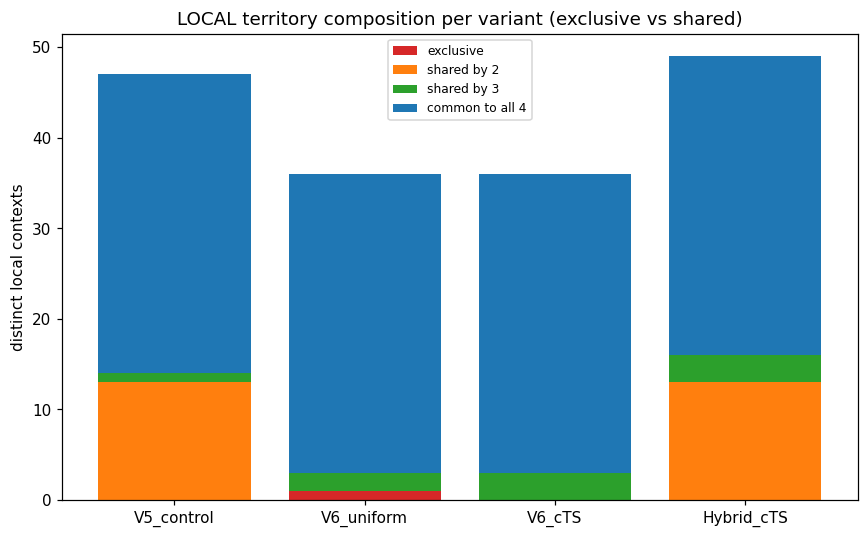

In [7]:
d2h_lib.show(d2h_lib.fig_composition(d, 'local'))

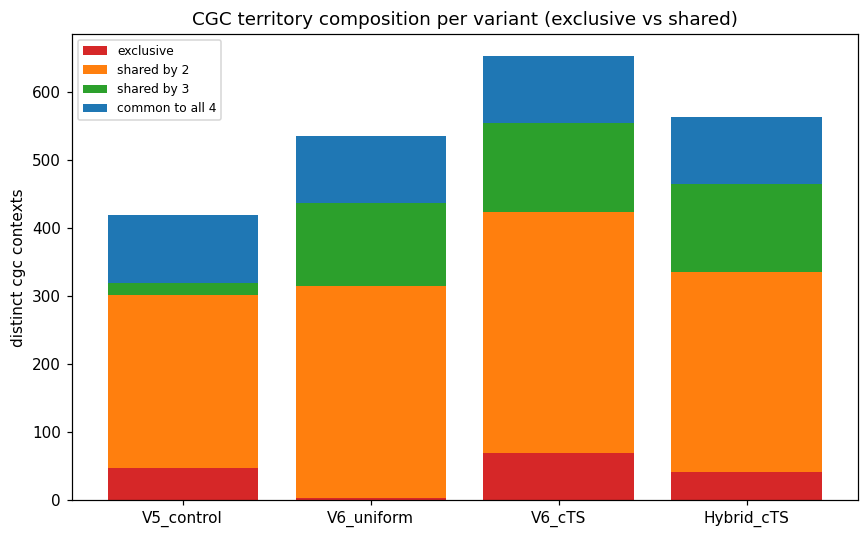

In [8]:
d2h_lib.show(d2h_lib.fig_composition(d, 'cgc'))

**What the decomposition shows (batch-1):**

- **Local territory is A4-dominated and heavily shared.** A4 (V5≈47, Hybrid≈49 locs) reaches more distinct local constraints than the Arguzz variants (≈36); most of the territory (≈33 of the ≈50-loc union) is common to all four. A4's single-cell witness mutations broadly trigger the per-row constraints. The Arguzz variants add **almost no** local-exclusive territory — the *one* local loc no A4 variant reached, `Poseidon0@inst_p2.zir:470`, was found only by **V6_uniform** (its round-robin happened to hit a Poseidon/hashing constraint). So **Hybrid reaches 49 of the 50-loc total — everything except that single Poseidon loc.**
- **CGC (global) territory is Arguzz-dominated and far richer.** V6_cTS reaches the most CGC contexts (≈653) with the largest exclusive/marginal contribution (≈69), and the union (≈1001) dwarfs the local union. The during-execution faults perturb the global permutation arguments much more than single-cell trace mutations do. **But A4 still contributes ≈47 exclusive CGC contexts** and Hybrid ≈42 — the global space is genuinely *contested*, not owned.
- **Hybrid is the combiner:** best-in-class local breadth (49/50) *and* solid global reach (≈564 CGC) — it inherits A4's local territory and adds Arguzz's global territory.

## 3. Where in the circuit does each architecture look? (per-family coverage)

Raw loc counts don't say *which parts of the circuit* get probed. Grouping locs by **circuit family** (the `.zir` component — `mem`, instruction-decode, `u32`/arithmetic, `inst_control`, `inst_ecall`, `inst_mul`/`div`, `inst_p2` Poseidon, `inst_sha`, `one_hot`, …) shows each architecture's **reach** and, crucially, its **blind spots** — a family no variant probes is exactly where an underconstraint could sit undetected.

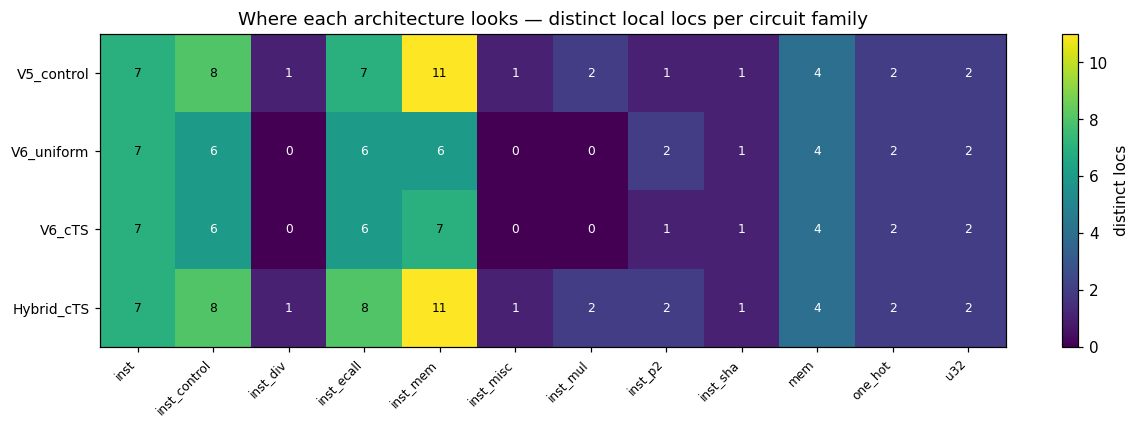

In [9]:
d2h_lib.show(d2h_lib.fig_family(d))

**Reading the heatmap.** Each cell = the number of distinct local locs a variant reached in that circuit family. It exposes (a) which families are well-covered vs barely-touched (blind-spot candidates), and (b) the **mechanism** behind the exclusive sets — the families where A4 and Arguzz diverge are where their surfaces genuinely differ.

## 4. Global-vs-local reach (CGC ÷ local)

A single ratio summarizes *where* on the local↔global axis each architecture concentrates its exploration: CGC contexts per local loc. A high ratio = a variant that reaches deep into the global/witness-internal permutation space relative to its local footprint.

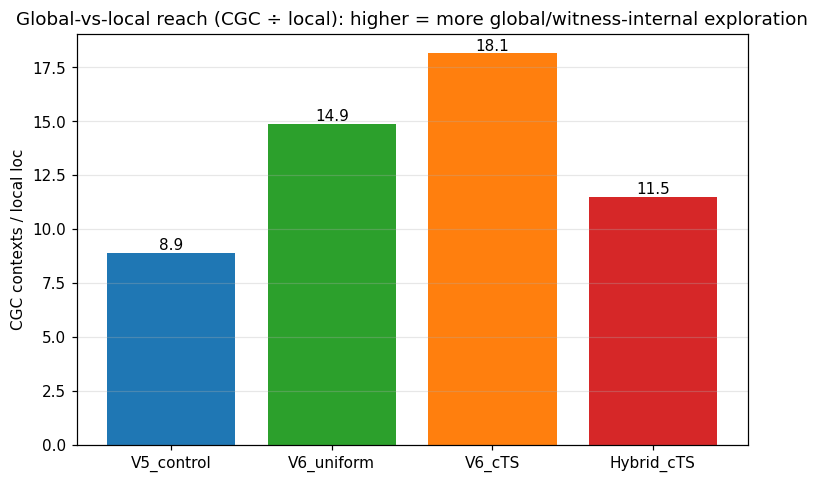

In [10]:
d2h_lib.show(d2h_lib.fig_cgc_ratio(d))

**This is the headline mechanistic finding — and it partially inverts a prior assumption.** The Arguzz variants have a much higher CGC/local ratio than A4. The pre-campaign framing ("A4's witness-internal mutations reach the *global* structures that execution-faults don't") is **not** what the data shows: **Arguzz-cTS reaches *more* CGC than A4, not less.** The honest reframing the data supports: the surfaces are **complementary but along the opposite axis than assumed** — **A4 ↔ broad *local* constraint coverage**, **Arguzz ↔ broad *global* (permutation) coverage** — and **Hybrid captures both**. This is the concrete, quantified version of the open "thesis may be inverted" question.

## 5. Discussion & caveats

**The exploration story (batch-1, provisional):**
- The four architectures explore **genuinely complementary** regions: A4 owns the local per-row constraint surface; Arguzz owns the global permutation surface; **Hybrid is the only variant strong on both** (49/50 local + ≈564 CGC).
- This **supports the Hybrid hypothesis on exploration grounds** (broadest combined reach) while **reframing the mechanism** (the complementarity axis is local-vs-global, and Arguzz — not A4 — is the global-reaching surface).
- Each architecture's **unique contribution** is real but asymmetric: A4 adds local breadth + ≈47 exclusive CGC; Arguzz-cTS adds ≈69 exclusive CGC; Hybrid adds the *combination* rather than a large novel-territory of its own.

**Caveats (do not over-read):**
1. **Provisional** — 2 of 3 seeds; magnitudes will shift with seed 1236.
2. **Exploration ≠ bugs** — D2.G triage = 0 confirmed soundness candidates so far; this is *potential*, not a finding.
3. **Sampling confound** — V6_cTS's cTS schedule over-samples high-arm-count kinds (e.g. INSTR_WORD_MOD), which inflates raw counts; the per-family view (§3) and the cross-variant comparison should be read with that in mind (the next notebook revision will report per-kind-normalized coverage).
4. **Single guest** — sha2-host. Some families (Poseidon `inst_p2`, BigInt) are guest-specific; multi-guest (IV.POS.9) would change the family-coverage picture and is where the currently-dead A4 paging/cycle kinds could activate.

**So what.** On exploration evidence, **Hybrid-cTS is the broadest explorer of the combined constraint space**, which is the right precondition for the soundness hunt — even though, at N=10000 on one guest, that hunt has so far surfaced no confirmed underconstraint.